In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('student_clustering.csv')
df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


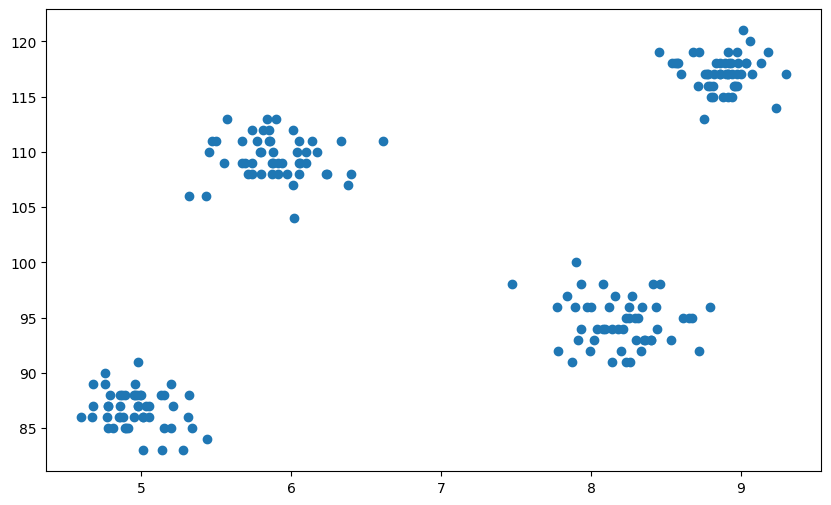

In [ ]:
plt.figure(figsize = (10 , 6))
plt.scatter(x = df['cgpa'] , y = df['iq'])
#Clearly we can see that 4 clusters will be made

In [7]:
from sklearn.cluster import KMeans

In [8]:
wcss = []
for i in range(1 , 11):
    km = KMeans(n_clusters=i)
    km.fit_predict(df)
    wcss.append(km.inertia_)


In [9]:
wcss

[29957.898287999997,
 4184.14127,
 2362.713349,
 681.96966,
 563.7685674520718,
 405.12058406910546,
 351.8910014460547,
 273.37883541396496,
 251.78171923039002,
 201.61473393018173]

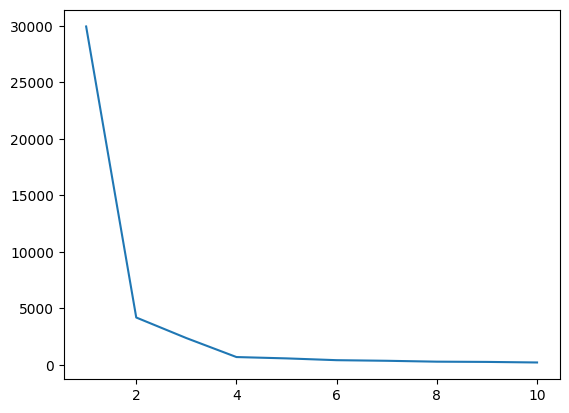

In [11]:
#We need to plot between the wcss and the number of clusters
plt.plot(range(1, 11) , wcss)
#At 4 we can see we get the best result

In [14]:
X = df.iloc[: , :].values
km = KMeans(n_clusters= 4)
y_means = km.fit_predict(X)

In [ ]:
#All the 
X[y_means == 0 , 1]
 #This gives all the points which is iq coming in 0 cluster

array([ 93.,  97.,  98.,  94.,  97.,  95.,  91.,  98.,  92.,  98.,  94.,
        96.,  96.,  96.,  93.,  94.,  96.,  96.,  95.,  93.,  95.,  94.,
        92.,  91.,  92.,  95.,  94.,  95.,  92.,  94.,  91.,  95.,  93.,
        97.,  98.,  96.,  93., 100.,  96.,  94.,  95.,  93.,  92.,  98.,
        96.,  93.,  91.,  93.,  94.,  96.])

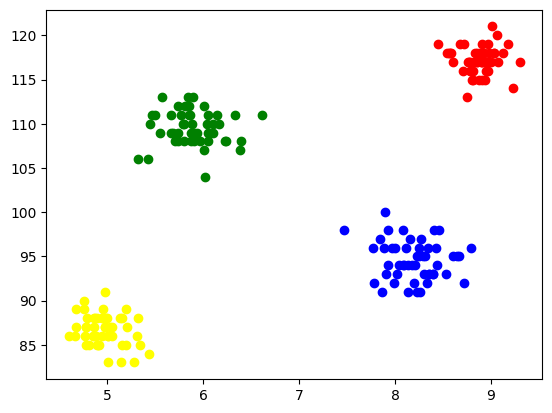

In [18]:
plt.scatter(X[y_means == 0 , 0 ], X[y_means ==  0 , 1] , color = 'blue')
plt.scatter(X[y_means == 1 , 0 ], X[y_means ==  1 , 1] , color = 'green')
plt.scatter(X[y_means == 2 , 0 ], X[y_means ==  2 , 1] , color = 'red')
plt.scatter(X[y_means == 3 , 0 ], X[y_means ==  3 , 1] , color = 'yellow')


### K-Means on 3-D data ###

In [19]:
from sklearn.datasets import make_blobs

centroids = [(-5,-5,5),(5,5,-5),(3.5,-2.5,4),(-2.5,2.5,-4)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=200,cluster_std=cluster_std,centers=centroids,n_features=3,random_state=1)

In [20]:
X

array([[ 4.33424548,  3.32580419, -4.17497018],
       [-3.32246719,  3.22171129, -4.625342  ],
       [-6.07296862, -4.13459237,  2.6984613 ],
       [ 6.90465871,  6.1110567 , -4.3409502 ],
       [-2.60839207,  2.95015551, -2.2346649 ],
       [ 5.88490881,  4.12271848, -5.86778722],
       [-4.68484061, -4.15383935,  4.14048406],
       [-1.82542929,  3.96089238, -3.4075272 ],
       [-5.34385368, -4.95640314,  4.37999916],
       [ 4.91549197,  4.70263812, -4.582698  ],
       [-3.80108212, -4.81484358,  4.62471505],
       [ 4.6735005 ,  3.65732421, -3.88561702],
       [-6.23005814, -4.4494625 ,  5.79280687],
       [-3.90232915,  2.95112294, -4.6949209 ],
       [ 3.72744124,  5.31354772, -4.49681519],
       [-3.3088472 ,  3.05743945, -3.81896126],
       [ 2.70273021, -2.21732429,  3.17390257],
       [ 4.06438286, -0.36217193,  3.214466  ],
       [ 4.69268607, -2.73794194,  5.15528789],
       [ 4.1210827 , -1.5438783 ,  3.29415949],
       [-6.61577235, -3.87858229,  5.408

In [22]:
import plotly.express as px
fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2])
fig.show()



In [23]:


wcss = []
for i in range(1,21):
    km = KMeans(n_clusters=i)
    km.fit_predict(X)
    wcss.append(km.inertia_)



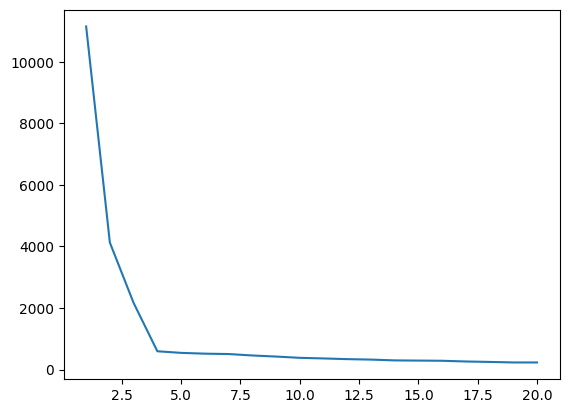

In [24]:
plt.plot(range(1,21),wcss)

In [25]:
km = KMeans(n_clusters=4)
y_pred = km.fit_predict(X)



In [26]:
df = pd.DataFrame()

df['col1'] = X[:,0]
df['col2'] = X[:,1]
df['col3'] = X[:,2]
df['label'] = y_pred

In [27]:


fig = px.scatter_3d(df,x='col1', y='col2', z='col3',color='label')
fig.show()

